# Introductory task for Applied Artificial Intelligence Lab

## Relevant information

I am an ERASMUS student, so I am only here for this semester. 

During my last semester in France, I passed a class about data analysis where I learned how to process and clean the data. I also learned about PCA, CCA, FCA and clustering algorithms.

Another class was about regression algorithms, where I applied linear regression, logistic regression with regularization such as Lasso and Ridge.

# Rainy or Sunny classifier

In [38]:
import os
import pandas as pd
import torch.nn as nn
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from PIL import Image
import re
import csv
import matplotlib.pyplot as plt
import torch

In [39]:
weather_to_idx = {"rainy": 0, "sunny": 1}

class WeatherDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = Image.open(img_path).convert("RGB")
        label_name = self.img_labels.iloc[idx, 1]
        label = weather_to_idx[label_name]
        if self.transform:
            image = self.transform(image)
        return image, label

In [40]:
img_path = "data/all_except_marked"

data = []
for filename in os.listdir(img_path):
    if filename.lower().endswith(('.png')):
        match = re.match(r"image_\d*(\D+)_(\w+)\.\w+", filename)
        if match:
            style = match.group(1)   # "realistic"
            weather = match.group(2) # "rainy"
            data.append([filename, weather, style])
        else:
            print(f"Nom inattendu : {filename}")
            
csv_path = os.path.join(img_path, "image_metadata.csv")
with open(csv_path, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["filename", "weather", "style"])
    writer.writerows(data)

In [41]:
first_dataset = WeatherDataset(annotations_file=csv_path, img_dir=img_path)

train_size = int(0.8 * len(first_dataset))
test_size = len(first_dataset) - train_size

train_dataset, test_dataset = random_split(first_dataset, [train_size, test_size])

In [42]:
len(train_dataset), len(test_dataset)

(128, 32)

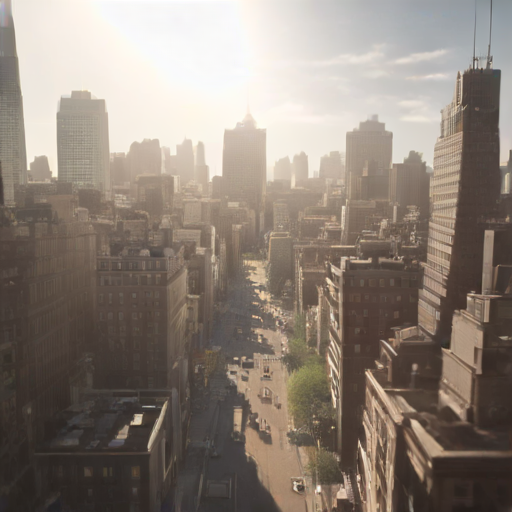

In [43]:
image, label = train_dataset[0]
image

In [44]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

first_dataset = WeatherDataset(annotations_file=csv_path, img_dir=img_path, transform=transform)

train_size = int(0.8 * len(first_dataset))
test_size = len(first_dataset) - train_size

train_dataset, test_dataset = random_split(first_dataset, [train_size, test_size])

In [45]:
image, label = train_dataset[0]
image.shape

torch.Size([3, 128, 128])

In [46]:
dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [47]:
class WeatherClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super(WeatherClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)